In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df = pd.read_csv('results/memory_catapult_sweep.csv')
df = df.rename(columns={'complexity': 'beam_width'})
print(df.shape)
df.head()

(20, 18)


,catapult,beam_width,seed,count,avg_qps,avg_dists_computed,p50_dists_computed,p95_dists_computed,avg_nodes_visited,p50_nodes_visited,p95_nodes_visited,avg_latency_us,p50_latency_us,p95_latency_us,catapult_usage_pct,avg_recall,p50_recall,p95_recall
0,off,1,NaN,10000,2274.308604,185.5775,176.0,357.00,4.9678,5.0,8.05,363.673507,335.055496,746.125858,0.00,0.1677,0.0,1.0
1,on,1,42.0,10000,3155.938646,107.3918,85.0,277.00,3.3087,3.0,7.00,246.160077,199.087997,614.611588,94.85,0.1847,0.0,1.0
2,on,1,43.0,10000,3044.327926,111.3747,91.0,285.00,3.4112,3.0,7.00,256.419791,210.190002,639.449020,94.15,0.1849,0.0,1.0
3,on,1,44.0,10000,3247.455339,102.2346,78.0,266.05,3.1800,3.0,7.00,237.223801,186.038498,612.252814,95.60,0.1889,0.0,1.0
4,off,2,NaN,10000,1725.209127,241.4919,229.5,446.00,7.3028,7.0,12.00,503.473602,466.110504,971.657083,0.00,0.2743,0.0,1.0


In [3]:
# Average 'on' rows across seeds; keep 'off' as-is (no seed)
on = df[df['catapult'] == 'on'].groupby(['catapult', 'beam_width']).agg(
    avg_qps=('avg_qps', 'mean'),
    avg_dists_computed=('avg_dists_computed', 'mean'),
    p50_dists_computed=('p50_dists_computed', 'mean'),
    p95_dists_computed=('p95_dists_computed', 'mean'),
    avg_nodes_visited=('avg_nodes_visited', 'mean'),
    p50_nodes_visited=('p50_nodes_visited', 'mean'),
    p95_nodes_visited=('p95_nodes_visited', 'mean'),
    avg_latency_us=('avg_latency_us', 'mean'),
    p50_latency_us=('p50_latency_us', 'mean'),
    p95_latency_us=('p95_latency_us', 'mean'),
    catapult_usage_pct=('catapult_usage_pct', 'mean'),
    avg_recall=('avg_recall', 'mean'),
    p50_recall=('p50_recall', 'mean'),
    p95_recall=('p95_recall', 'mean'),
).reset_index()

off = df[df['catapult'] == 'off'][['catapult', 'beam_width',
    'avg_qps', 'avg_dists_computed', 'p50_dists_computed', 'p95_dists_computed',
    'avg_nodes_visited', 'p50_nodes_visited', 'p95_nodes_visited',
    'avg_latency_us', 'p50_latency_us', 'p95_latency_us', 'catapult_usage_pct',
    'avg_recall', 'p50_recall', 'p95_recall']]

agg = pd.concat([on, off], ignore_index=True).sort_values(['catapult', 'beam_width'])

beam_widths = sorted(agg['beam_width'].unique())

colors = {'on': '#1f77b4', 'off': '#ff7f0e'}
markers = {'on': 'o', 'off': 's'}
labels_map = {'on': 'catapult on', 'off': 'catapult off'}

os.makedirs('figures/filtered', exist_ok=True)
print('figures/filtered/ ready')

figures/filtered/ ready


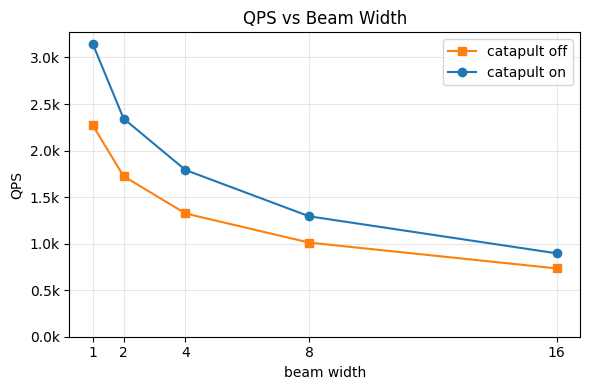

In [4]:
# Plot 1: QPS vs beam_width
agg[['catapult', 'beam_width', 'avg_qps']].to_csv('figures/filtered/plot1_qps_vs_beam_width.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 4))
for cat in ['off', 'on']:
    sub = agg[agg['catapult'] == cat].sort_values('beam_width')
    ax.plot(sub['beam_width'], sub['avg_qps'],
            marker=markers[cat], color=colors[cat], label=labels_map[cat])
ax.set_xlabel('beam width')
ax.set_ylabel('QPS')
ax.set_xticks(beam_widths)
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}k'))
ax.set_title('QPS vs Beam Width')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/filtered/plot1_qps_vs_beam_width.png', dpi=150)
plt.show()

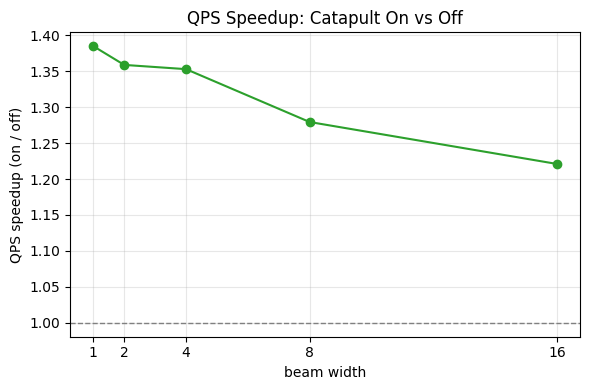

In [5]:
# Plot 2: QPS speedup (catapult on / catapult off)
qps_off = agg[agg['catapult'] == 'off'].set_index('beam_width')['avg_qps']
qps_on  = agg[agg['catapult'] == 'on'].set_index('beam_width')['avg_qps']
speedup = (qps_on / qps_off).reset_index()
speedup.columns = ['beam_width', 'speedup']
speedup.to_csv('figures/filtered/plot2_qps_speedup.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(speedup['beam_width'], speedup['speedup'], marker='o', color='#2ca02c')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('beam width')
ax.set_ylabel('QPS speedup (on / off)')
ax.set_xticks(beam_widths)
ax.set_title('QPS Speedup: Catapult On vs Off')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/filtered/plot2_qps_speedup.png', dpi=150)
plt.show()

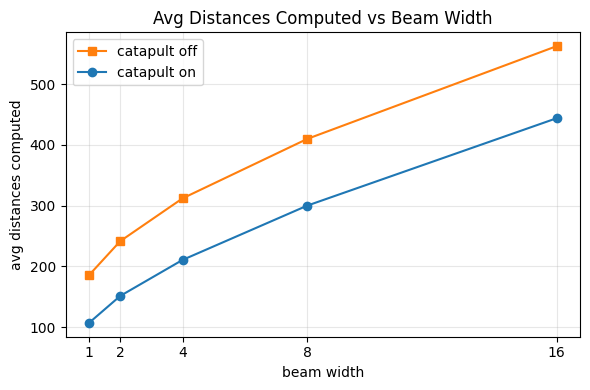

In [6]:
# Plot 3: Avg distances computed vs beam_width
agg[['catapult', 'beam_width', 'avg_dists_computed']].to_csv('figures/filtered/plot3_avg_dists.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 4))
for cat in ['off', 'on']:
    sub = agg[agg['catapult'] == cat].sort_values('beam_width')
    ax.plot(sub['beam_width'], sub['avg_dists_computed'],
            marker=markers[cat], color=colors[cat], label=labels_map[cat])
ax.set_xlabel('beam width')
ax.set_ylabel('avg distances computed')
ax.set_xticks(beam_widths)
ax.set_title('Avg Distances Computed vs Beam Width')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/filtered/plot3_avg_dists.png', dpi=150)
plt.show()

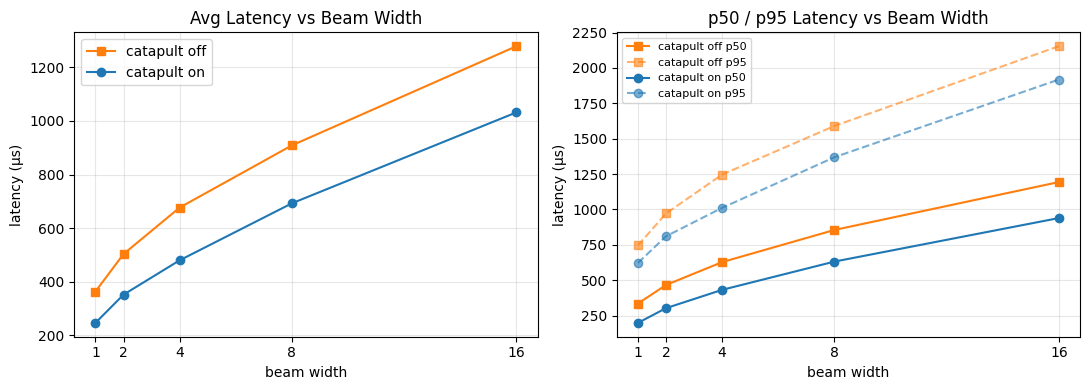

In [7]:
# Plot 4: Latency (avg / p50 / p95) vs beam_width — two subplots
agg[['catapult', 'beam_width', 'avg_latency_us', 'p50_latency_us', 'p95_latency_us']].to_csv('figures/filtered/plot4_latency.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for cat in ['off', 'on']:
    sub = agg[agg['catapult'] == cat].sort_values('beam_width')
    axes[0].plot(sub['beam_width'], sub['avg_latency_us'],
                 marker=markers[cat], color=colors[cat], label=labels_map[cat])
axes[0].set_xlabel('beam width')
axes[0].set_ylabel('latency (µs)')
axes[0].set_xticks(beam_widths)
axes[0].set_title('Avg Latency vs Beam Width')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for cat in ['off', 'on']:
    sub = agg[agg['catapult'] == cat].sort_values('beam_width')
    axes[1].plot(sub['beam_width'], sub['p50_latency_us'],
                 marker=markers[cat], color=colors[cat], linestyle='-',
                 label=f'{labels_map[cat]} p50')
    axes[1].plot(sub['beam_width'], sub['p95_latency_us'],
                 marker=markers[cat], color=colors[cat], linestyle='--',
                 label=f'{labels_map[cat]} p95', alpha=0.6)
axes[1].set_xlabel('beam width')
axes[1].set_ylabel('latency (µs)')
axes[1].set_xticks(beam_widths)
axes[1].set_title('p50 / p95 Latency vs Beam Width')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('figures/filtered/plot4_latency.png', dpi=150)
plt.show()

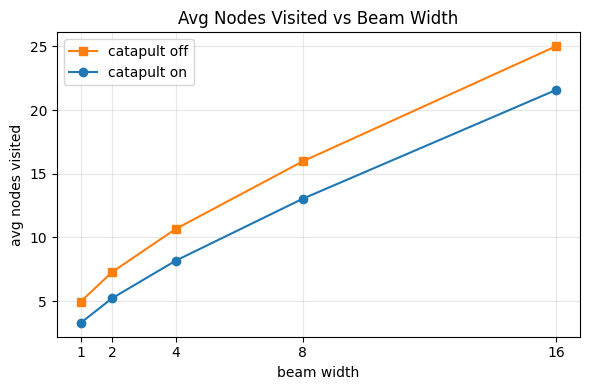

In [8]:
# Plot 5: Avg nodes visited vs beam_width
agg[['catapult', 'beam_width', 'avg_nodes_visited']].to_csv('figures/filtered/plot5_avg_nodes.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 4))
for cat in ['off', 'on']:
    sub = agg[agg['catapult'] == cat].sort_values('beam_width')
    ax.plot(sub['beam_width'], sub['avg_nodes_visited'],
            marker=markers[cat], color=colors[cat], label=labels_map[cat])
ax.set_xlabel('beam width')
ax.set_ylabel('avg nodes visited')
ax.set_xticks(beam_widths)
ax.set_title('Avg Nodes Visited vs Beam Width')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/filtered/plot5_avg_nodes.png', dpi=150)
plt.show()

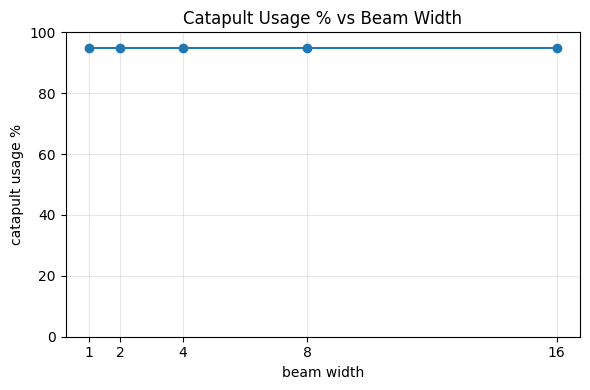

In [9]:
# Plot 6: Catapult usage % vs beam_width (catapult-on rows only)
cat_on = agg[agg['catapult'] == 'on'].sort_values('beam_width')
cat_on[['beam_width', 'catapult_usage_pct']].to_csv('figures/filtered/plot6_catapult_usage.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cat_on['beam_width'], cat_on['catapult_usage_pct'], marker='o', color='#1f77b4')
ax.set_xlabel('beam width')
ax.set_ylabel('catapult usage %')
ax.set_xticks(beam_widths)
ax.set_ylim(0, 100)
ax.set_title('Catapult Usage % vs Beam Width')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/filtered/plot6_catapult_usage.png', dpi=150)
plt.show()

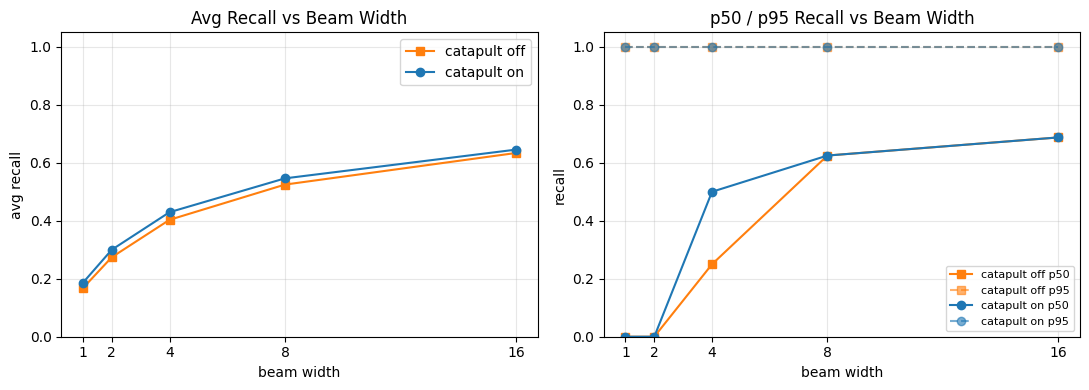

In [10]:
# Plot 7: Recall vs beam_width (avg, p50, p95)
agg[['catapult', 'beam_width', 'avg_recall', 'p50_recall', 'p95_recall']].to_csv('figures/filtered/plot7_recall.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for cat in ['off', 'on']:
    sub = agg[agg['catapult'] == cat].sort_values('beam_width')
    axes[0].plot(sub['beam_width'], sub['avg_recall'],
                 marker=markers[cat], color=colors[cat], label=labels_map[cat])
axes[0].set_xlabel('beam width')
axes[0].set_ylabel('avg recall')
axes[0].set_xticks(beam_widths)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Avg Recall vs Beam Width')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for cat in ['off', 'on']:
    sub = agg[agg['catapult'] == cat].sort_values('beam_width')
    axes[1].plot(sub['beam_width'], sub['p50_recall'],
                 marker=markers[cat], color=colors[cat], linestyle='-',
                 label=f'{labels_map[cat]} p50')
    axes[1].plot(sub['beam_width'], sub['p95_recall'],
                 marker=markers[cat], color=colors[cat], linestyle='--',
                 label=f'{labels_map[cat]} p95', alpha=0.6)
axes[1].set_xlabel('beam width')
axes[1].set_ylabel('recall')
axes[1].set_xticks(beam_widths)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('p50 / p95 Recall vs Beam Width')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('figures/filtered/plot7_recall.png', dpi=150)
plt.show()

In [12]:
# Relative % difference: catapult on vs off, per beam_width (already averaged over seeds in agg)

baseline = agg[agg['catapult'] == 'off'].set_index('beam_width')
cat_on   = agg[agg['catapult'] == 'on'].set_index('beam_width')

metrics = [
    'avg_qps', 'avg_dists_computed', 'avg_nodes_visited',
    'avg_latency_us', 'p50_latency_us', 'p95_latency_us',
    'avg_recall', 'p50_recall', 'p95_recall',
]

rows = []
for bw in sorted(cat_on.index):
    row = {'beam_width': bw, 'catapult_usage_pct': cat_on.loc[bw, 'catapult_usage_pct']}
    for m in metrics:
        v = baseline.loc[bw, m] if bw in baseline.index else float('nan')
        s = cat_on.loc[bw, m]
        row[f'{m}_rel_pct'] = (s - v) / abs(v) * 100 if (not pd.isna(v) and not pd.isna(s) and v != 0) else float('nan')
    rows.append(row)

rel_df = pd.DataFrame(rows)
rel_df.to_csv('figures/filtered/rel_pct_diff.csv', index=False)
rel_df.round(2)

,beam_width,catapult_usage_pct,avg_qps_rel_pct,avg_dists_computed_rel_pct,avg_nodes_visited_rel_pct,avg_latency_us_rel_pct,p50_latency_us_rel_pct,p95_latency_us_rel_pct,avg_recall_rel_pct,p50_recall_rel_pct,p95_recall_rel_pct
0,1,94.87,38.47,-42.34,-33.57,-32.19,-40.77,-16.62,11.01,NaN,0.0
1,2,94.87,35.87,-37.33,-28.17,-30.10,-35.10,-16.57,9.39,NaN,0.0
2,4,94.87,35.28,-32.48,-23.33,-29.06,-31.21,-18.87,6.52,100.0,0.0
3,8,94.87,27.93,-26.79,-18.36,-23.78,-26.13,-13.90,4.10,0.0,0.0
4,16,94.87,22.10,-21.09,-13.71,-19.31,-21.32,-10.94,1.83,0.0,0.0
